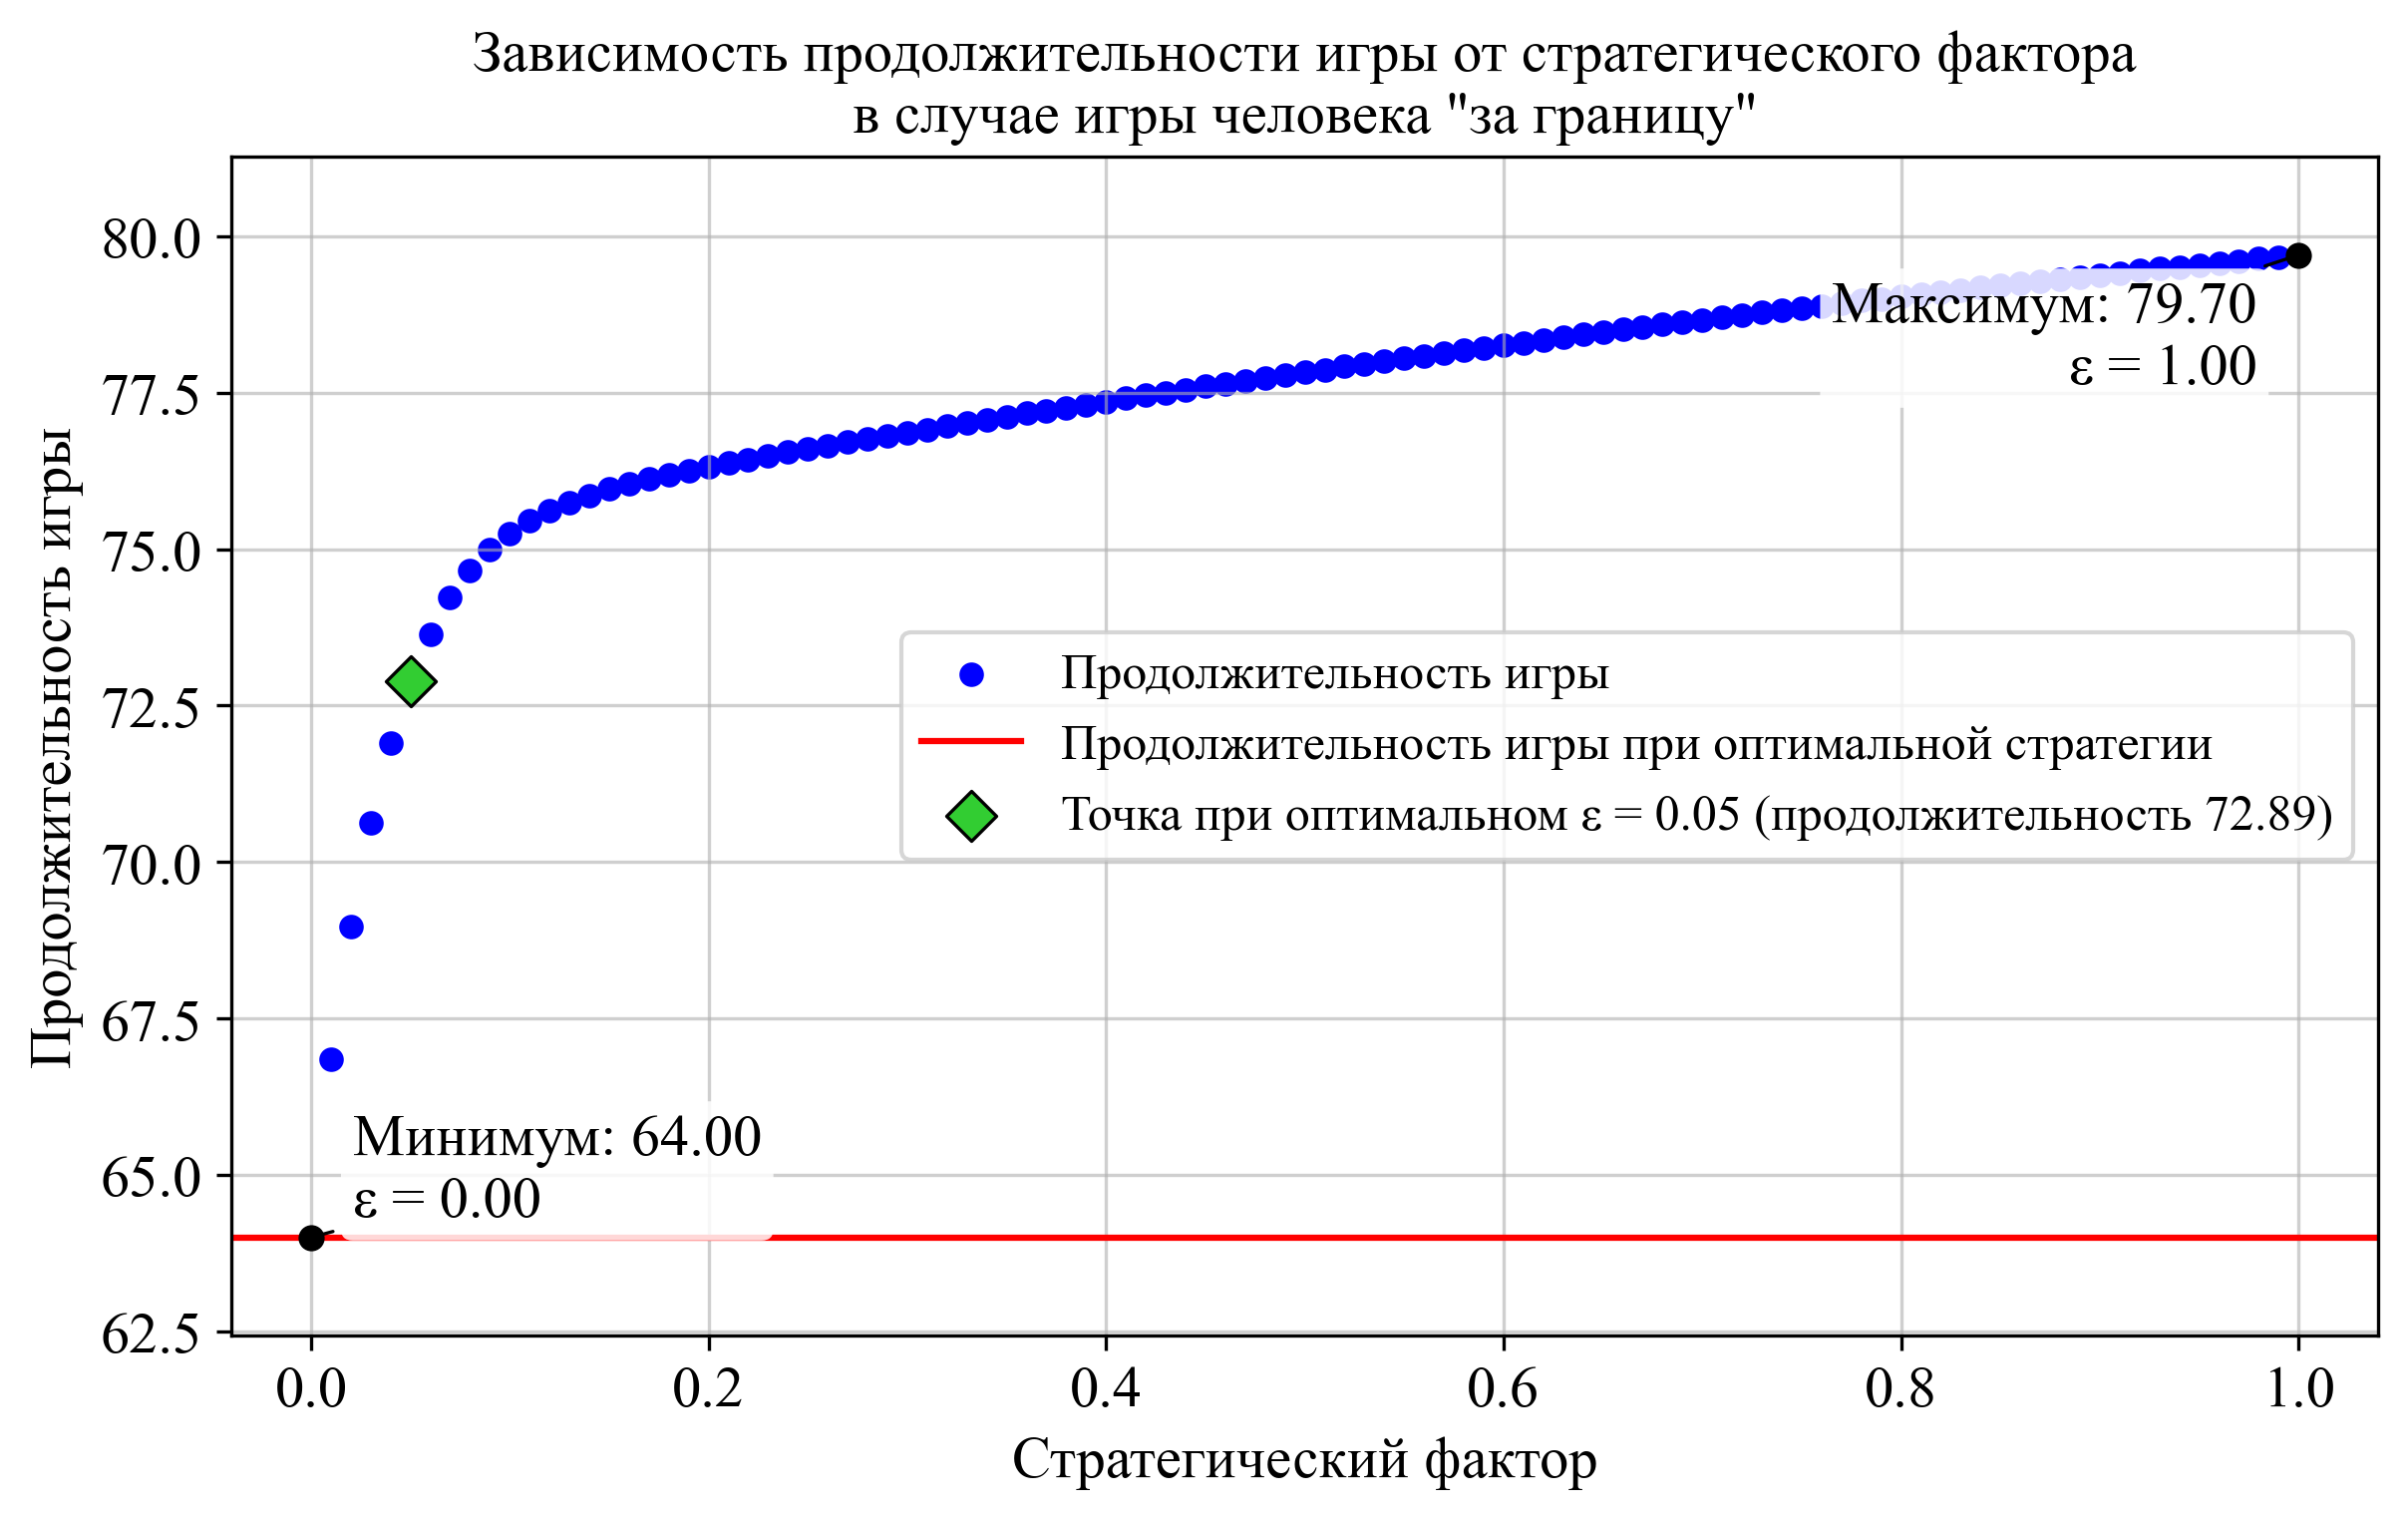

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

A4_WIDTH_INCHES = 8.27
A4_PLOT_HEIGHT_INCHES = 5.3

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

OPTIMAL_STRATEGY_DURATIONS = {
    "BvP": 64.0,
    "PvB": 225.0,
}


def load_sweep_data(output_dir):
    output_dir = Path(output_dir)
    epsilon_values = np.loadtxt(output_dir / "epsilon_values.txt", dtype=float)
    durations = np.loadtxt(output_dir / "absorption_time.txt", dtype=float)
    epsilon_values = np.atleast_1d(epsilon_values)
    durations = np.atleast_1d(durations)

    if epsilon_values.size != durations.size:
        raise ValueError(
            f"Количество epsilon ({epsilon_values.size}) не совпадает "
            f"с количеством длительностей ({durations.size})."
        )
    return epsilon_values, durations


def annotate_extrema(ax, epsilon_values, durations):
    min_index = int(np.nanargmin(durations))
    max_index = int(np.nanargmax(durations))

    extrema = [
        ("Минимум", min_index, 16),
        ("Максимум", max_index, -20),
    ]
    x_middle = 0.5 * (float(np.nanmin(epsilon_values)) + float(np.nanmax(epsilon_values)))
    for label, index, vertical_offset in extrema:
        x_value = float(epsilon_values[index])
        y_value = float(durations[index])
        is_right_side = x_value > x_middle
        horizontal_offset = -10 if is_right_side else 10
        horizontal_alignment = "right" if is_right_side else "left"
        ax.scatter(
            [x_value],
            [y_value],
            color="black",
            s=28,
            zorder=5,
        )
        ax.annotate(
            f"{label}: {y_value:.2f}\nε = {x_value:.2f}",
            xy=(x_value, y_value),
            xytext=(horizontal_offset, vertical_offset),
            textcoords="offset points",
            ha=horizontal_alignment,
            va="center",
            fontsize=14,
            fontfamily="Times New Roman",
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.85},
            arrowprops={"arrowstyle": "-", "color": "black", "lw": 0.8},
        )


def plot_duration_sweep(
    epsilon_values,
    durations,
    game_case,
    title,
    output_path,
    *,
    min_epsilon=None,
    log_scale=False,
    optimal_epsilon=None,
):
    epsilon_values = np.asarray(epsilon_values, dtype=float)
    durations = np.asarray(durations, dtype=float)

    if min_epsilon is not None:
        mask = epsilon_values >= min_epsilon
        epsilon_values = epsilon_values[mask]
        durations = durations[mask]

    fig, ax = plt.subplots(
        figsize=(A4_WIDTH_INCHES, A4_PLOT_HEIGHT_INCHES),
        dpi=300,
    )
    ax.scatter(
        epsilon_values,
        durations,
        color="blue",
        s=24,
        label="Продолжительность игры",
    )

    optimal_duration = OPTIMAL_STRATEGY_DURATIONS.get(game_case)
    if optimal_duration is not None:
        ax.axhline(
            optimal_duration,
            color="red",
            linestyle="-",
            linewidth=1.5,
            label="Продолжительность игры при оптимальной стратегии",
        )

    if optimal_epsilon is not None:
        optimal_index = int(np.nanargmin(np.abs(epsilon_values - optimal_epsilon)))
        plotted_epsilon = float(epsilon_values[optimal_index])
        plotted_duration = float(durations[optimal_index])
        ax.scatter(
            [plotted_epsilon],
            [plotted_duration],
            color="limegreen",
            edgecolor="black",
            linewidth=0.8,
            marker="D",
            s=72,
            zorder=6,
            label=(
                f"Точка при оптимальном ε = {plotted_epsilon:.2f} "
                f"(продолжительность {plotted_duration:.2f})"
            ),
        )

    annotate_extrema(ax, epsilon_values, durations)

    ax.set_xlabel("Стратегический фактор")
    ax.set_ylabel("Продолжительность игры")
    ax.set_title(title)
    ax.grid(True, alpha=0.6)
    ax.margins(x=0.04, y=0.10)

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ScalarFormatter())

    ax.legend(
        prop={"family": "Times New Roman", "size": 12},
        loc="best",
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


bvp_try_num = 21
optimal_epsilon_bvp = 0.05
bvp_output_dir = Path(
    f"D:/RW/RWAnalyzer/output/eps_quarter/bvp/try_{bvp_try_num}"
)
bvp_epsilon_values, bvp_durations = load_sweep_data(bvp_output_dir)

plot_duration_sweep(
    bvp_epsilon_values,
    bvp_durations,
    game_case="BvP",
    title=(
        "Зависимость продолжительности игры от стратегического фактора\nв случае игры человека \"за границу\""
    ),
    output_path=bvp_output_dir / "epsilon_vs_duration_new.png",
    min_epsilon=0.0,
    optimal_epsilon=optimal_epsilon_bvp,
)


In [ ]:
pvb_try_num = 12
optimal_epsilon_pvb = 0.80  # Задается вручную
pvb_output_dir = Path(
    f"D:/RW/RWAnalyzer/output/eps_border/pvb/try_{pvb_try_num}"
)
pvb_epsilon_values, pvb_durations = load_sweep_data(pvb_output_dir)

plot_duration_sweep(
    pvb_epsilon_values,
    pvb_durations,
    game_case="PvB",
    title=(
        "Зависимость количества очков от предвзятости, зависящей от расстояния "
        "до ближайшей границы,\n"
        "в случае игры человека за центр против компьютера (логарифмическая шкала)"
    ),
    output_path=pvb_output_dir / "epsilon_vs_duration_log.png",
    log_scale=True,
    optimal_epsilon=optimal_epsilon_pvb,
)
